In [26]:
import torch
words = open('names.txt',mode='r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}

In [ ]:
len(stoi)


{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [27]:
#构建三维滑动窗口数据集
block_size = 3
X,Y = [],[]

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
    
X = torch.tensor(X)
Y = torch.tensor(Y)

print("-----基建完成-----")
print(f"X shape:{X.shape}")
print(f"Y shape:{Y.shape}")

-----基建完成-----
X shape:torch.Size([228146, 3])
Y shape:torch.Size([228146])


In [28]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27,2),generator=g)


emb = C[X]
print(f"原始 X 形状: {X.shape}")
print(f"嵌入后 emb 形状: {emb.shape}")


原始 X 形状: torch.Size([228146, 3])
嵌入后 emb 形状: torch.Size([228146, 3, 2])


In [30]:
hidden_size = 100

#初始化隐藏层参数
W1 = torch.randn((6,hidden_size),generator=g)
b1 = torch.randn(hidden_size,generator=g)

#前向传播与.view()处理
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

print(f"隐藏层输出h的形状:{h.shape}")

隐藏层输出h的形状:torch.Size([228146, 100])


In [32]:
import torch.nn.functional as F

# 初始化输出层的参数
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)

#计算原始打分
logits = h @ W2 + b2
print(f"Logits形状:{logits.shape}")

#交叉熵损失
loss = F.cross_entropy(logits,Y)

print(f"初始Loss:{loss.item():.4f}")


Logits形状:torch.Size([228146, 27])
初始Loss:17.0265


In [39]:
parameters = [C,W1,W2,b1,b2]

print(f"模型的总参数量:{sum(p.nelement() for p in parameters)}")

for p in parameters:
    p.requires_grad = True

#训练循环
epochs = 1000
batch_size = 32
learning_rate = 0.1

for k in range(epochs):
    #mini-batch构造
    ix = torch.randint(0,X.shape[0],(batch_size,))

    #forward propagation
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits,Y[ix])

    #backward propagation
    for p in parameters:
        p.grad = None
    loss.backward()

    #mini_SGD updata
    for p in parameters:
        p.data += -learning_rate * p.grad
    
    if k % 50 == 0:
        print(f"Epoch:{k:4d}   |   Loss:{loss.item():.4f}")

print(f"训练结束,当前MiniBatch Loss:{loss.item():.4f}")


模型的总参数量:3481
Epoch:   0   |   Loss:3.0567
Epoch:  50   |   Loss:3.2619
Epoch: 100   |   Loss:2.9536
Epoch: 150   |   Loss:2.5679
Epoch: 200   |   Loss:2.8559
Epoch: 250   |   Loss:2.8365
Epoch: 300   |   Loss:2.8799
Epoch: 350   |   Loss:2.5103
Epoch: 400   |   Loss:2.4863
Epoch: 450   |   Loss:2.5994
Epoch: 500   |   Loss:2.6102
Epoch: 550   |   Loss:2.8109
Epoch: 600   |   Loss:2.5711
Epoch: 650   |   Loss:2.3287
Epoch: 700   |   Loss:2.6589
Epoch: 750   |   Loss:2.8811
Epoch: 800   |   Loss:2.9920
Epoch: 850   |   Loss:2.4670
Epoch: 900   |   Loss:2.5884
Epoch: 950   |   Loss:2.5854
训练结束,当前MiniBatch Loss:2.5918


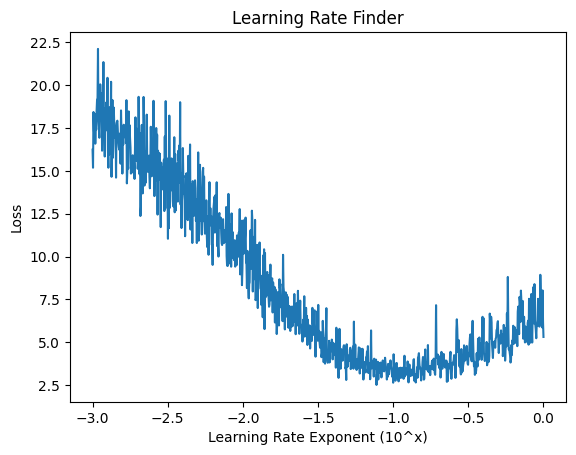

In [47]:
import matplotlib.pyplot as plt

g = torch.Generator().manual_seed(2147473647)
C = torch.randn((27,2),generator=g)

W1 = torch.randn((6,hidden_size),generator=g)
b1 = torch.randn(hidden_size,generator=g)
W2 = torch.randn((hidden_size,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

#生成100个探索性的学习率
lre = torch.linspace(-3,0,1000)    #范围从10^-3~1
lrs = 10**lre

lri = []
lossi = []

for i in range(1000):
    ix = torch.randint(0,X.shape[0],(32,))

    emd = C[X[ix]]
    h = torch.tanh(emd.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])

    for p in parameters:
        p.grad = None
    loss.backward()


    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lre[i])
    lossi.append(loss.item())



# 4. 把探索结果画出来！
plt.plot(lri, lossi)
plt.title("Learning Rate Finder")
plt.xlabel("Learning Rate Exponent (10^x)")
plt.ylabel("Loss")
plt.show()

In [51]:
# 1. 彻底重置所有参数，回到起跑线
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,hidden_size),generator=g)
b1 = torch.randn(hidden_size,generator=g)
W2 = torch.randn((hidden_size,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

# 准备空列表，用来记录我们下山的轨迹
stepi = []
lossi = []

print("🚀 终极训练开始，请稍候...")

# 2. 狂奔 30,000 步！
for i in range(30000):
    
    # 构建 Minibatch (每次随机抽 32 个样本)
    ix = torch.randint(0, X.shape[0], (32,))
    
    # 前向传播
    emb = C[X] 
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Y)
    
    # 反向传播
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # --- 核心工程技巧：学习率衰减 (Learning Rate Decay) ---
    # 前 20,000 步，用 0.1 的大步子快速冲刺
    # 后 10,000 步，Loss 很难降了，把步子缩减到 0.01 进行微调
    lr = 0.1 if i < 20000 else 0.01
    
    # 梯度更新
    for p in parameters:
        p.data += -lr * p.grad
        
    # 记录脚印
    stepi.append(i)
    lossi.append(loss.item())
    
    # 显示进度
    if i % 1000 == 0 or i == 29999:
        print(f"Step {i+1}/30000 | Loss: {loss.item():.4f}")


print(f"🏁 30,000步训练结束！最后一次 Minibatch 的 Loss: {loss.item():.4f}")

 
        
# 3. 画出 Loss 的下降曲线
plt.plot(stepi, lossi)
plt.title("Training Loss Curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

🚀 终极训练开始，请稍候...
Step 1/30000 | Loss: 19.5052


KeyboardInterrupt: 